# Telco Customer Churn — Adaptation au Contexte Marocain (Gestion de flotte téléphonique & IA)

## Objectif
Ce notebook a pour but de construire un modèle de prédiction du **churn** (résiliation client) à partir du dataset *Telco Customer Churn*, puis de transformer ces résultats en éléments directement exploitables pour un projet de **gestion intelligente de flotte téléphonique** au Maroc.

## Résultats attendus
- Nettoyage et préparation des données (qualité, valeurs manquantes, encodage).
- Entraînement de modèles de Machine Learning pour prédire le churn.
- Création d’un **scoring de risque (0–100)** permettant de prioriser les clients/lignes à surveiller.
- Construction d’indicateurs (KPIs) et génération d’alertes (risque élevé, coût élevé, roaming suspect).
- Production de fichiers exportables pour alimenter un **dashboard décisionnel** et un système d’alertes.

## Intérêt pour le projet "Gestion de flotte"
L’approche IA permet de détecter plus tôt les risques (coûts excessifs, comportements anormaux, churn), de proposer des actions d’optimisation (forfaits, limitation, contrôle roaming) et d’aider les managers à prendre des décisions rapides et basées sur des données.

In [1]:
# ============================================================
# CELLULE 1 — TITRE & OBJECTIF DU NOTEBOOK
# ============================================================
# Objectif : traiter le dataset Telco Customer Churn et construire un modèle
# de prédiction du churn + préparer des indicateurs utiles pour un projet
# de gestion de flotte téléphonique (coûts, segments, risque, recommandations).

print("✅ Notebook : Telco Customer Churn — Prétraitement + ML + Adaptation Gestion de Flotte (Maroc)")

✅ Notebook : Telco Customer Churn — Prétraitement + ML + Adaptation Gestion de Flotte (Maroc)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LinearRegression

In [3]:
import os

# Trouver automatiquement le fichier CSV dans /kaggle/input
base_path = "/kaggle/input"
csv_path = None

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.lower().endswith(".csv") and "telco" in f.lower():
            csv_path = os.path.join(root, f)
            break

print("CSV trouvé :", csv_path)

df = pd.read_csv(csv_path)
df.head()

CSV trouvé : /kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df = df.copy()

# customerID n'est pas utile pour les modèles
if "customerID" in df.columns:
    df.drop(columns=["customerID"], inplace=True)

# TotalCharges parfois en texte avec espaces -> conversion
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

# Target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [5]:
df_ma = df.copy()

# ---- Simulation contexte Maroc (exemple réaliste PFE) ----
np.random.seed(42)

# Opérateurs au Maroc (simulation)
operators = ["Maroc Telecom", "Orange Maroc", "inwi"]
df_ma["operator"] = np.random.choice(operators, size=len(df_ma), p=[0.45, 0.30, 0.25])

# Départements entreprise (flotte)
departments = ["IT", "Finance", "RH", "Commercial", "Support", "Direction"]
df_ma["department"] = np.random.choice(departments, size=len(df_ma), p=[0.18, 0.15, 0.12, 0.25, 0.20, 0.10])

# Budget mensuel simulé par ligne (MAD) — basé sur MonthlyCharges mais converti "style Maroc"
# (ce dataset est US, on adapte en MAD pour le scénario)
USD_TO_MAD = 10.0  # approximation pour scénario (tu peux ajuster)
df_ma["monthly_cost_mad"] = (df_ma["MonthlyCharges"] * USD_TO_MAD).round(2)

# Total en MAD
df_ma["total_cost_mad"] = (df_ma["TotalCharges"] * USD_TO_MAD).round(2)

# Forfait simulé en fonction du coût (tiers)
def plan_from_cost(c):
    if c < 150:
        return "S"
    elif c < 300:
        return "M"
    elif c < 500:
        return "L"
    return "XL"

df_ma["plan"] = df_ma["monthly_cost_mad"].apply(plan_from_cost)

# Simuler Roaming (0/1) selon départements + opérateur
prob_roaming = np.where(df_ma["department"].isin(["Commercial", "Direction"]), 0.30, 0.10)
df_ma["roaming_flag"] = (np.random.rand(len(df_ma)) < prob_roaming).astype(int)

# Simuler la consommation data (GB) plus réaliste
df_ma["data_usage_gb"] = (
    df_ma["MonthlyCharges"] / 2 + np.random.normal(0, 3, len(df_ma))
).clip(0).round(2)
# Simuler un plafond forfait (quota) selon plan
quota_map = {"S": 5, "M": 12, "L": 25, "XL": 50}
df_ma["quota_gb"] = df_ma["plan"].map(quota_map)

# Dépassement (surconsommation) : data_usage > quota
df_ma["over_quota_flag"] = (df_ma["data_usage_gb"] > df_ma["quota_gb"]).astype(int)

df_ma.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Churn,operator,department,monthly_cost_mad,total_cost_mad,plan,roaming_flag,data_usage_gb,quota_gb,over_quota_flag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,0,Maroc Telecom,IT,298.5,298.5,M,0,14.82,12,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,inwi,Direction,569.5,18895.0,XL,1,27.62,50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,1,Orange Maroc,RH,538.5,1081.5,XL,1,30.95,50,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,0,Orange Maroc,Support,423.0,18407.5,L,0,24.10,25,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,1,Maroc Telecom,IT,707.0,1516.5,XL,0,32.03,50,0


In [6]:
# KPI globaux (exemple mensuel)
kpi = {
    "Coût total mensuel (MAD)": df_ma["monthly_cost_mad"].sum(),
    "Coût moyen par ligne (MAD)": df_ma["monthly_cost_mad"].mean(),
    "Nb lignes en dépassement quota": int(df_ma["over_quota_flag"].sum()),
    "Taux dépassement (%)": round(df_ma["over_quota_flag"].mean() * 100, 2),
    "Nb lignes roaming": int(df_ma["roaming_flag"].sum()),
}

kpi_df = pd.DataFrame([kpi])
kpi_df

,Coût total mensuel (MAD),Coût moyen par ligne (MAD),Nb lignes en dépassement quota,Taux dépassement (%),Nb lignes roaming
0,4561166.0,647.616925,1624,23.06,1175


In [7]:
# Features numériques pour anomalies
anom_features = df_ma[["monthly_cost_mad", "data_usage_gb", "tenure", "roaming_flag", "over_quota_flag"]].copy()

scaler = StandardScaler()
X_anom = scaler.fit_transform(anom_features)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,  # 3% anomalies (ajuste selon ton besoin)
    random_state=42
)

anom_pred = iso.fit_predict(X_anom)  # -1 anomalie
df_ma["anomaly_flag"] = (anom_pred == -1).astype(int)

df_ma["anomaly_flag"].value_counts()

anomaly_flag
0    6831
1     212
Name: count, dtype: int64

In [8]:
target = "Churn"

features = [
    "gender","SeniorCitizen","Partner","Dependents","tenure","PhoneService","MultipleLines",
    "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod",
    "MonthlyCharges","TotalCharges",
    # colonnes Maroc
    "operator","department","plan","monthly_cost_mad","total_cost_mad","roaming_flag","data_usage_gb","quota_gb","over_quota_flag","anomaly_flag"
]

X = df_ma[features].copy()
y = df_ma[target].copy()

num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC AUC:", round(roc_auc_score(y_test, proba), 4))

# Risk scoring
df_ma["risk_proba"] = pipe.predict_proba(X)[:, 1]
df_ma["risk_score_100"] = (df_ma["risk_proba"] * 100).round(1)

def risk_level(score):
    if score >= 80: return "Critique"
    if score >= 50: return "Élevé"
    if score >= 20: return "Moyen"
    return "Faible"

df_ma["risk_level"] = df_ma["risk_score_100"].apply(risk_level)

df_ma[["monthly_cost_mad","data_usage_gb","over_quota_flag","anomaly_flag","risk_score_100","risk_level"]].head(10)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.80      0.79      1409

ROC AUC: 0.837


,monthly_cost_mad,data_usage_gb,over_quota_flag,anomaly_flag,risk_score_100,risk_level
0,298.5,14.82,1,0,26.0,Moyen
1,569.5,27.62,0,0,2.0,Faible
2,538.5,30.95,0,0,81.0,Critique
3,423.0,24.10,0,0,1.5,Faible
4,707.0,32.03,0,0,83.8,Critique
5,996.5,50.97,1,0,98.0,Critique
6,891.0,50.23,1,0,51.0,Élevé
7,297.5,18.98,1,0,23.2,Moyen
8,1048.0,49.67,0,0,85.0,Critique
9,561.5,32.86,0,0,4.0,Faible


In [9]:
# Objectif : prédire monthly_cost_mad "prochain mois" (simulé)
# On crée une cible future artificielle: coût futur = coût actuel + bruit + effet dépassement/roaming
df_ma["future_cost_mad"] = (
    df_ma["monthly_cost_mad"]
    + df_ma["over_quota_flag"] * np.random.uniform(20, 80, len(df_ma))
    + df_ma["roaming_flag"] * np.random.uniform(30, 120, len(df_ma))
    + np.random.normal(0, 15, len(df_ma))
).clip(0).round(2)

# Features simples pour prédire future_cost_mad
Xf = df_ma[["monthly_cost_mad","data_usage_gb","tenure","roaming_flag","over_quota_flag","quota_gb"]]
yf = df_ma["future_cost_mad"]

sc = StandardScaler()
Xf_scaled = sc.fit_transform(Xf)

lr = LinearRegression()
lr.fit(Xf_scaled, yf)

df_ma["future_cost_pred_mad"] = lr.predict(Xf_scaled).round(2)

df_ma[["monthly_cost_mad","future_cost_mad","future_cost_pred_mad","over_quota_flag","roaming_flag"]].head(10)

,monthly_cost_mad,future_cost_mad,future_cost_pred_mad,over_quota_flag,roaming_flag
0,298.5,368.01,348.71,1,0
1,569.5,663.16,645.23,0,1
2,538.5,641.54,615.74,0,1
3,423.0,465.03,423.10,0,0
4,707.0,733.76,707.19,0,0
5,996.5,1038.16,1047.19,1,0
6,891.0,940.18,942.13,1,0
7,297.5,349.58,348.23,1,0
8,1048.0,1065.24,1047.81,0,0
9,561.5,579.32,561.76,0,0


In [10]:
# Règles simples d'alertes (mix IA + règles métier)
df_ma["alert_flag"] = 0
df_ma.loc[(df_ma["anomaly_flag"] == 1) | (df_ma["risk_level"].isin(["Élevé","Critique"])) | (df_ma["over_quota_flag"]==1), "alert_flag"] = 1

def recommendation(row):
    if row["risk_level"] in ["Critique","Élevé"] and row["over_quota_flag"]==1:
        return "Proposer upgrade forfait + vérifier usage"
    if row["roaming_flag"]==1 and row["anomaly_flag"]==1:
        return "Vérifier roaming + limiter options"
    if row["over_quota_flag"]==1:
        return "Proposer forfait supérieur"
    if row["risk_level"] in ["Critique","Élevé"]:
        return "Surveiller la ligne + analyser causes"
    return "RAS"

df_ma["recommendation"] = df_ma.apply(recommendation, axis=1)

df_ma[["operator","department","plan","monthly_cost_mad","data_usage_gb","quota_gb","over_quota_flag","anomaly_flag","risk_level","alert_flag","recommendation"]].head(20)

,operator,department,plan,monthly_cost_mad,data_usage_gb,quota_gb,over_quota_flag,anomaly_flag,risk_level,alert_flag,recommendation
0,Maroc Telecom,IT,M,298.5,14.82,12,1,0,Moyen,1,Proposer forfait supérieur
1,inwi,Direction,XL,569.5,27.62,50,0,0,Faible,0,RAS
2,Orange Maroc,RH,XL,538.5,30.95,50,0,0,Critique,1,Surveiller la ligne + analyser causes
3,Orange Maroc,Support,L,423.0,24.10,25,0,0,Faible,0,RAS
4,Maroc Telecom,IT,XL,707.0,32.03,50,0,0,Critique,1,Surveiller la ligne + analyser causes
5,Maroc Telecom,Finance,XL,996.5,50.97,50,1,0,Critique,1,Proposer upgrade forfait + vérifier usage
6,Maroc Telecom,Commercial,XL,891.0,50.23,50,1,0,Élevé,1,Proposer upgrade forfait + vérifier usage
7,inwi,Support,M,297.5,18.98,12,1,0,Moyen,1,Proposer forfait supérieur
8,Orange Maroc,Commercial,XL,1048.0,49.67,50,0,0,Critique,1,Surveiller la ligne + analyser causes
9,Orange Maroc,Direction,XL,561.5,32.86,50,0,0,Faible,0,RAS


In [11]:
# Export du dataset final
out_path = "fleet_ai_results_morocco.csv"

df_ma.to_csv(out_path, sep=";", index=False)

print("Export généré :", out_path)


# ============================================================
# CELLULE — TOP ALERTES (lignes les plus critiques)
# ============================================================

top_alerts = df_ma[df_ma["alert_flag"] == 1] \
    .sort_values(["risk_score_100", "monthly_cost_mad"], ascending=False) \
    .head(15)

top_alerts

Export généré : fleet_ai_results_morocco.csv


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,quota_gb,over_quota_flag,anomaly_flag,risk_proba,risk_score_100,risk_level,future_cost_mad,future_cost_pred_mad,alert_flag,recommendation
4800,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9925,99.2,Critique,921.66,941.01,1,Surveiller la ligne + analyser causes
6933,Male,0,No,No,1,Yes,No,Fiber optic,No,No,...,50,0,0,0.9900,99.0,Critique,692.01,696.42,1,Surveiller la ligne + analyser causes
1410,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9875,98.8,Critique,944.72,939.13,1,Surveiller la ligne + analyser causes
3209,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9875,98.8,Critique,943.27,939.18,1,Surveiller la ligne + analyser causes
983,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9875,98.8,Critique,861.45,867.08,1,Surveiller la ligne + analyser causes
5288,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,50,0,0,0.9875,98.8,Critique,805.15,797.48,1,Surveiller la ligne + analyser causes
969,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9850,98.5,Critique,961.75,960.29,1,Surveiller la ligne + analyser causes
2191,Female,1,No,No,1,Yes,No,Fiber optic,No,No,...,50,0,0,0.9850,98.5,Critique,905.49,913.41,1,Surveiller la ligne + analyser causes
3749,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,50,0,0,0.9825,98.2,Critique,920.25,939.13,1,Surveiller la ligne + analyser causes
970,Female,0,No,No,1,Yes,No,Fiber optic,No,No,...,50,0,0,0.9825,98.2,Critique,885.14,906.70,1,Surveiller la ligne + analyser causes


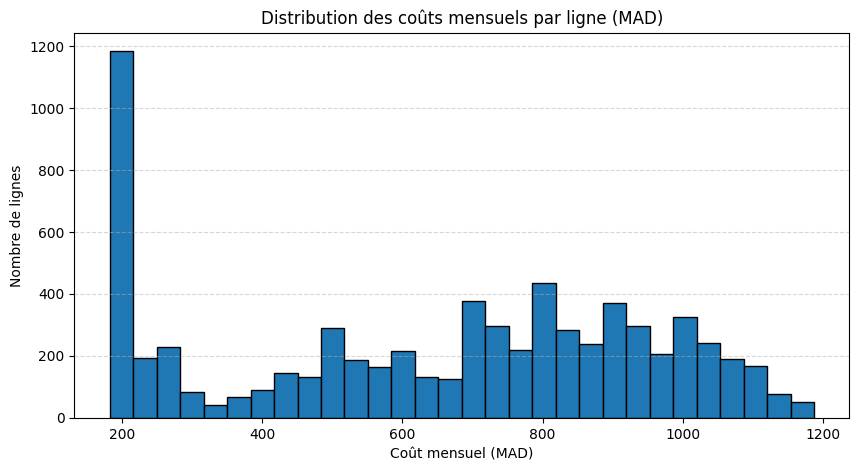

In [12]:
# ============================================================
# CELLULE — VISUALISATION 1 : Distribution des coûts mensuels
# ============================================================

plt.figure(figsize=(10, 5))
plt.hist(df_ma["monthly_cost_mad"], bins=30, edgecolor="black")
plt.title("Distribution des coûts mensuels par ligne (MAD)")
plt.xlabel("Coût mensuel (MAD)")
plt.ylabel("Nombre de lignes")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

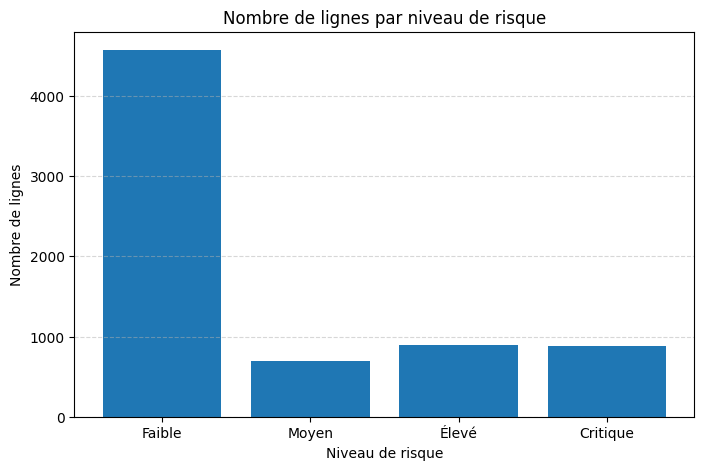

In [13]:
# ============================================================
# CELLULE — VISUALISATION 2 : Nombre de lignes par niveau de risque
# ============================================================

risk_counts = df_ma["risk_level"].value_counts().reindex(["Faible", "Moyen", "Élevé", "Critique"], fill_value=0)

plt.figure(figsize=(8, 5))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Nombre de lignes par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre de lignes")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

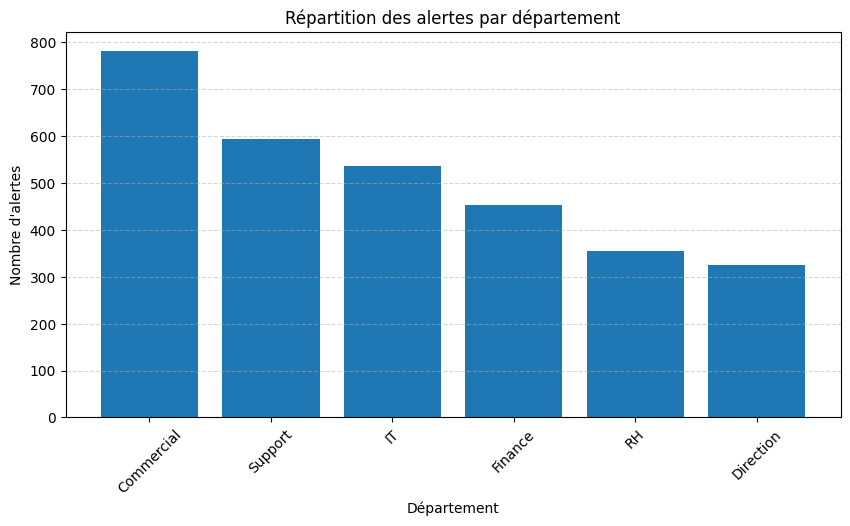

In [14]:
# ============================================================
# CELLULE — VISUALISATION 3 : Répartition des alertes par département
# ============================================================

alert_dept = df_ma[df_ma["alert_flag"] == 1]["department"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(alert_dept.index, alert_dept.values)
plt.title("Répartition des alertes par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'alertes")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

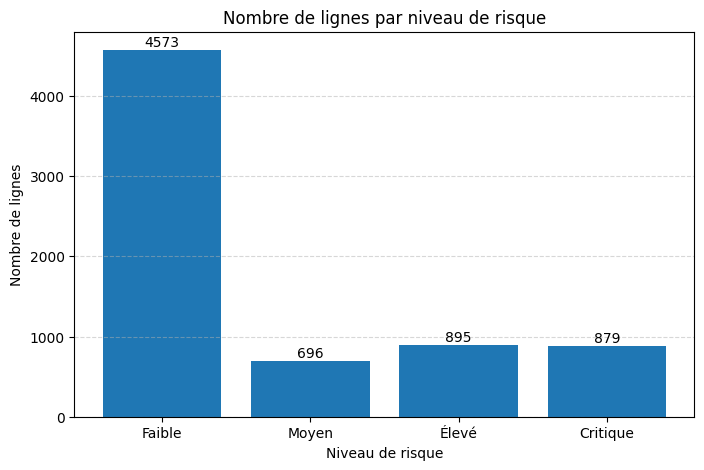

In [15]:
# ============================================================
# CELLULE — VISUALISATION 2 BIS : Nombre de lignes par niveau de risque
# ============================================================

risk_counts = df_ma["risk_level"].value_counts().reindex(["Faible", "Moyen", "Élevé", "Critique"], fill_value=0)

plt.figure(figsize=(8, 5))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Nombre de lignes par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre de lignes")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')

plt.show()

In [16]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [17]:
# ============================================================
# IMPORT DES LIBRAIRIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [18]:
# ============================================================
# CHARGEMENT DU DATASET
# ============================================================

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [19]:
# ============================================================
# EXPLORATION DES DONNEES
# ============================================================

print(df.shape)

print(df.columns)

print(df.dtypes)

print(df["Churn"].value_counts())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
Churn


In [20]:
# ============================================================
# NETTOYAGE DE TotalCharges
# ============================================================

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [21]:
# ============================================================
# ENCODAGE DE LA VARIABLE CIBLE
# ============================================================

df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [22]:
# ============================================================
# SUPPRESSION COLONNE customerID
# ============================================================

df = df.drop("customerID", axis=1)

In [23]:
# ============================================================
# ENCODAGE DES VARIABLES CATEGORIELLES
# ============================================================

df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                           False  ...                            Fa

In [24]:
# ============================================================
# SEPARATION DES DONNEES
# ============================================================

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [25]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# ============================================================
# MODELE — XGBOOST CLASSIFIER
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("✅ Modèle XGBoost entraîné avec succès")

✅ Modèle XGBoost entraîné avec succès


In [27]:
# ============================================================
# PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Prédictions terminées")

✅ Prédictions terminées


In [28]:
# ============================================================
# EVALUATION DU MODELE
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_proba), 4))

print("\nClassification Report :\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix :\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7942
ROC AUC  : 0.834

Classification Report :

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Confusion Matrix :

[[922 113]
 [177 197]]


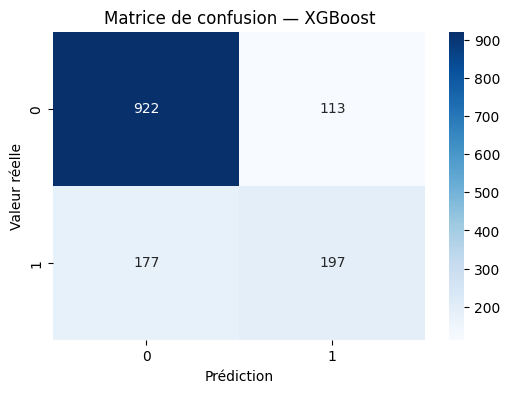

In [29]:
# ============================================================
# MATRICE DE CONFUSION VISUELLE
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de confusion — XGBoost")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.show()

In [30]:
# ============================================================
# SCORING DE RISQUE SUR TOUT LE DATASET
# ============================================================

df_encoded["risk_proba"] = xgb_model.predict_proba(X)[:, 1]
df_encoded["risk_score_100"] = (df_encoded["risk_proba"] * 100).round(1)

def risk_level(score):
    if score >= 80:
        return "Critique"
    elif score >= 50:
        return "Élevé"
    elif score >= 20:
        return "Moyen"
    else:
        return "Faible"

df_encoded["risk_level"] = df_encoded["risk_score_100"].apply(risk_level)

df_encoded[["risk_proba", "risk_score_100", "risk_level"]].head()

,risk_proba,risk_score_100,risk_level
0,0.545505,54.599998,Élevé
1,0.020508,2.100000,Faible
2,0.491987,49.200001,Moyen
3,0.022797,2.300000,Faible
4,0.642904,64.300003,Élevé


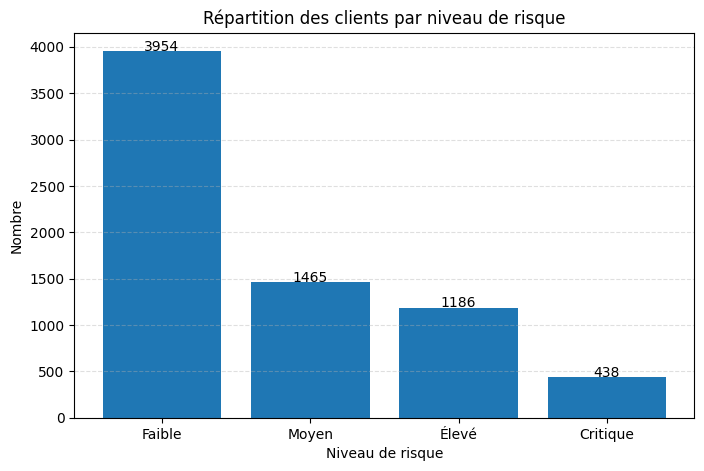

In [31]:
# ============================================================
# REPARTITION DES NIVEAUX DE RISQUE
# ============================================================

risk_counts = df_encoded["risk_level"].value_counts().reindex(
    ["Faible", "Moyen", "Élevé", "Critique"],
    fill_value=0
)

plt.figure(figsize=(8, 5))
bars = plt.bar(risk_counts.index, risk_counts.values)

plt.title("Répartition des clients par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha="center")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [32]:
# ============================================================
# TOP CLIENTS LES PLUS RISQUES
# ============================================================

top_risk = df_encoded.sort_values("risk_score_100", ascending=False).head(15)

top_risk[["risk_score_100", "risk_level", "Churn"]]

,risk_score_100,risk_level,Churn
4517,97.500000,Critique,1
2631,97.099998,Critique,1
3349,97.099998,Critique,1
4800,97.000000,Critique,1
1976,97.000000,Critique,1
39,96.699997,Critique,1
6623,96.599998,Critique,1
2464,96.599998,Critique,1
7032,96.599998,Critique,1
2577,96.599998,Critique,1


In [33]:
# ============================================================
# IMPORTANCE DES VARIABLES
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

                                 Feature  Importance
25                     Contract_Two year    0.225347
10           InternetService_Fiber optic    0.189060
24                     Contract_One year    0.078408
11                    InternetService_No    0.075347
12    OnlineSecurity_No internet service    0.073306
16  DeviceProtection_No internet service    0.035507
28        PaymentMethod_Electronic check    0.028851
1                                 tenure    0.026569
23                   StreamingMovies_Yes    0.023254
8         MultipleLines_No phone service    0.017329
26                  PaperlessBilling_Yes    0.016976
13                    OnlineSecurity_Yes    0.016869
19                       TechSupport_Yes    0.016684
3                           TotalCharges    0.016069
7                       PhoneService_Yes    0.015905


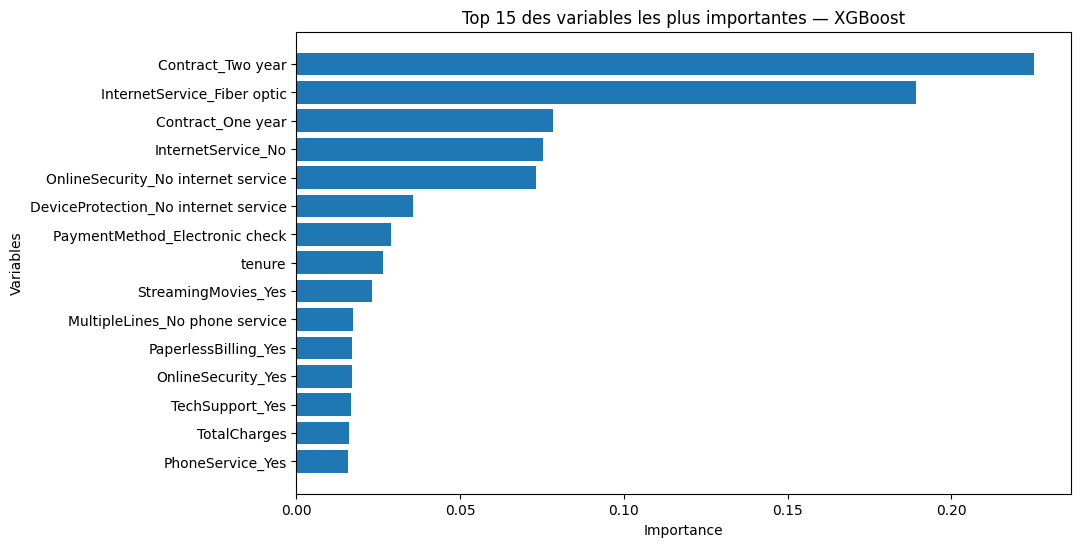

In [34]:
# ============================================================
# VISUALISATION DES VARIABLES LES PLUS IMPORTANTES
# ============================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 des variables les plus importantes — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

In [35]:
# ============================================================
# EXPORT DES RESULTATS
# ============================================================

df_results = df_encoded.copy()
df_results.to_csv("xgboost_telco_results.csv", index=False)

print("✅ Fichier exporté : xgboost_telco_results.csv")

✅ Fichier exporté : xgboost_telco_results.csv


In [36]:
# ============================================================
# ALERTES ET RECOMMANDATIONS
# ============================================================

df_encoded["alert_flag"] = (df_encoded["risk_level"].isin(["Élevé", "Critique"])).astype(int)

def recommendation(row):
    if row["risk_level"] == "Critique":
        return "Intervention immédiate / revoir contrat"
    elif row["risk_level"] == "Élevé":
        return "Surveiller le client et proposer une action préventive"
    elif row["risk_level"] == "Moyen":
        return "Suivi recommandé"
    else:
        return "RAS"

df_encoded["recommendation"] = df_encoded.apply(recommendation, axis=1)

df_encoded[["risk_score_100", "risk_level", "alert_flag", "recommendation"]].head(10)

,risk_score_100,risk_level,alert_flag,recommendation
0,54.599998,Élevé,1,Surveiller le client et proposer une action pr...
1,2.100000,Faible,0,RAS
2,49.200001,Moyen,0,Suivi recommandé
3,2.300000,Faible,0,RAS
4,64.300003,Élevé,1,Surveiller le client et proposer une action pr...
5,94.400002,Critique,1,Intervention immédiate / revoir contrat
6,37.099998,Moyen,0,Suivi recommandé
7,12.400000,Faible,0,RAS
8,79.199997,Élevé,1,Surveiller le client et proposer une action pr...
9,1.600000,Faible,0,RAS


## Conclusion — Modèle XGBoost

Le modèle **XGBoost** a été utilisé pour prédire le churn des clients à partir du dataset **Telco Customer Churn**.  
Les résultats obtenus montrent que ce modèle offre de bonnes performances pour un problème de classification binaire.

### Résultats obtenus
- **Accuracy : 79.42 %**
- **ROC-AUC : 0.834**

Ces résultats montrent que le modèle est globalement capable de bien distinguer les clients susceptibles de résilier leur abonnement de ceux qui restent fidèles.

### Analyse des performances
L’analyse du **classification report** montre que le modèle prédit mieux la classe **0 (non churn)** que la classe **1 (churn)**.  
Cela s’explique notamment par le fait que le dataset est **déséquilibré**, avec un nombre plus élevé de clients non churn que de clients churn.

Malgré cela, le modèle reste pertinent car :
- il identifie correctement une grande partie des clients à risque,
- il fournit une probabilité de churn exploitable,
- il permet de construire un **score de risque sur 100**.

### Variables les plus importantes
Les variables les plus influentes dans la prédiction sont principalement :
- le **type de contrat**,
- le **type de service Internet**,
- l’**ancienneté du client (tenure)**,
- le **mode de paiement**,
- le **montant total facturé**.

Ces variables sont cohérentes avec le comportement réel des clients et renforcent la crédibilité du modèle.

### Intérêt pour le projet de gestion de flotte téléphonique
Dans le cadre du projet **Gestion intelligente de flotte téléphonique au Maroc**, ce modèle est particulièrement utile car il permet de :

- détecter les lignes ou clients les plus à risque,
- prioriser les actions grâce à un **scoring de risque**,
- générer des **alertes automatiques**,
- proposer des **recommandations de suivi ou d’optimisation**.

Ainsi, XGBoost constitue une solution pertinente pour intégrer de l’intelligence artificielle dans un système d’aide à la décision orienté **pilotage des coûts**, **surveillance des lignes** et **anticipation des risques**.

In [37]:
# ============================================================
# MODELE 3 — LOGISTIC REGRESSION (BASELINE)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardisation des données
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle Logistic Regression
log_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    solver="lbfgs"
)

# Entrainement
log_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression entraîné avec succès")

✅ Logistic Regression entraîné avec succès


In [38]:
# ============================================================
# PREDICTIONS LOGISTIC REGRESSION
# ============================================================

log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:,1]

print("✅ Prédictions terminées")

✅ Prédictions terminées


In [39]:
# ============================================================
# EVALUATION LOGISTIC REGRESSION
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy :", round(accuracy_score(y_test, log_pred),4))
print("ROC AUC :", round(roc_auc_score(y_test, log_proba),4))

print("\nClassification Report :\n")
print(classification_report(y_test, log_pred))

print("\nConfusion Matrix :\n")
print(confusion_matrix(y_test, log_pred))

Accuracy : 0.7388
ROC AUC : 0.8412

Classification Report :

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Confusion Matrix :

[[749 286]
 [ 82 292]]


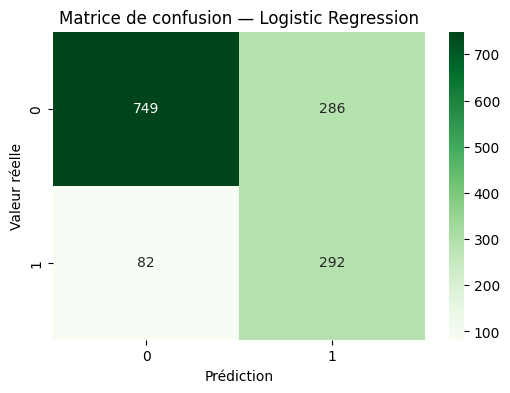

In [40]:
# ============================================================
# MATRICE DE CONFUSION LOGISTIC REGRESSION
# ============================================================

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Matrice de confusion — Logistic Regression")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")

plt.show()

In [41]:
# ============================================================
# RECREER TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# reconstruire X et y
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# refaire la séparation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Variables recréées :", X_train.shape, X_test.shape)

✅ Variables recréées : (5634, 35) (1409, 35)


In [42]:
# ============================================================
# CELLULE — RECONSTRUIRE UN DATASET PROPRE POUR LA COMPARAISON
# ============================================================

import pandas as pd
import numpy as np

# Repartir du df original déjà nettoyé/encodé avant les outputs
# Si df_encoded contient déjà des colonnes générées, on les enlève
cols_to_remove_if_exist = [
    "risk_proba", "risk_score_100", "risk_level",
    "alert_flag", "recommendation"
]

df_model = df_encoded.copy()

for col in cols_to_remove_if_exist:
    if col in df_model.columns:
        df_model = df_model.drop(columns=[col])

# Target
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (7043, 30)
Shape y : (7043,)


In [43]:
# ============================================================
# CELLULE — TRAIN / TEST SPLIT PROPRE
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Split OK :", X_train.shape, X_test.shape)

✅ Split OK : (5634, 30) (1409, 30)


In [44]:
# ============================================================
# CELLULE — COMPARAISON DE PLUSIEURS MODELES
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ]),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

trained_models = {}

for name, model in models.items():
    print(f"🔄 Entraînement : {name}")
    
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision_Churn": round(precision_score(y_test, y_pred), 4),
        "Recall_Churn": round(recall_score(y_test, y_pred), 4),
        "F1_Churn": round(f1_score(y_test, y_pred), 4),
        "ROC_AUC": round(roc_auc_score(y_test, y_proba), 4)
    })

results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df

🔄 Entraînement : Logistic Regression
🔄 Entraînement : Random Forest
🔄 Entraînement : Gradient Boosting
🔄 Entraînement : XGBoost


,Model,Accuracy,Precision_Churn,Recall_Churn,F1_Churn,ROC_AUC
2,Gradient Boosting,0.8027,0.6644,0.5187,0.5826,0.8435
0,Logistic Regression,0.7388,0.5052,0.7807,0.6134,0.8412
3,XGBoost,0.7942,0.6355,0.5267,0.5760,0.8340
1,Random Forest,0.7892,0.6296,0.5000,0.5574,0.8246


In [45]:
# ============================================================
# CELLULE — SELECTION DU MEILLEUR MODELE
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("✅ Meilleur modèle sélectionné :", best_model_name)
print(results_df)

✅ Meilleur modèle sélectionné : Gradient Boosting
                 Model  Accuracy  Precision_Churn  Recall_Churn  F1_Churn  \
2    Gradient Boosting    0.8027           0.6644        0.5187    0.5826   
0  Logistic Regression    0.7388           0.5052        0.7807    0.6134   
3              XGBoost    0.7942           0.6355        0.5267    0.5760   
1        Random Forest    0.7892           0.6296        0.5000    0.5574   

   ROC_AUC  
2   0.8435  
0   0.8412  
3   0.8340  
1   0.8246  


In [46]:
# ============================================================
# CELLULE — GENERATION DU OUTPUT FINAL AVEC LE MEILLEUR MODELE
# ============================================================

# Probabilité de churn sur tout le dataset
df_output = df_model.copy()

df_output["risk_proba"] = best_model.predict_proba(X)[:, 1]
df_output["risk_score_100"] = (df_output["risk_proba"] * 100).round(1)

def risk_level(score):
    if score >= 80:
        return "Critique"
    elif score >= 50:
        return "Élevé"
    elif score >= 20:
        return "Moyen"
    else:
        return "Faible"

df_output["risk_level"] = df_output["risk_score_100"].apply(risk_level)

# Alertes
df_output["alert_flag"] = (df_output["risk_level"].isin(["Élevé", "Critique"])).astype(int)

# Recommandations
def recommendation(row):
    if row["risk_level"] == "Critique":
        return "Intervention immédiate / revoir contrat / action commerciale urgente"
    elif row["risk_level"] == "Élevé":
        return "Surveiller le client et proposer une action préventive"
    elif row["risk_level"] == "Moyen":
        return "Suivi recommandé"
    else:
        return "RAS"

df_output["recommendation"] = df_output.apply(recommendation, axis=1)

print("✅ Output final généré avec :", best_model_name)
df_output[["risk_proba", "risk_score_100", "risk_level", "alert_flag", "recommendation"]].head(10)

✅ Output final généré avec : Gradient Boosting


,risk_proba,risk_score_100,risk_level,alert_flag,recommendation
0,0.532742,53.3,Élevé,1,Surveiller le client et proposer une action pr...
1,0.040428,4.0,Faible,0,RAS
2,0.542510,54.3,Élevé,1,Surveiller le client et proposer une action pr...
3,0.050005,5.0,Faible,0,RAS
4,0.651748,65.2,Élevé,1,Surveiller le client et proposer une action pr...
5,0.869626,87.0,Critique,1,Intervention immédiate / revoir contrat / acti...
6,0.400027,40.0,Moyen,0,Suivi recommandé
7,0.175741,17.6,Faible,0,RAS
8,0.586459,58.6,Élevé,1,Surveiller le client et proposer une action pr...
9,0.038252,3.8,Faible,0,RAS


In [47]:
# ============================================================
# CELLULE — TOP CLIENTS A RISQUE
# ============================================================

top_risk_final = df_output.sort_values("risk_score_100", ascending=False).head(20)

top_risk_final[["risk_score_100", "risk_level", "alert_flag", "recommendation", "Churn"]]

,risk_score_100,risk_level,alert_flag,recommendation,Churn
2208,94.4,Critique,1,Intervention immédiate / revoir contrat / acti...,1
6482,93.8,Critique,1,Intervention immédiate / revoir contrat / acti...,1
1704,92.9,Critique,1,Intervention immédiate / revoir contrat / acti...,1
4800,92.3,Critique,1,Intervention immédiate / revoir contrat / acti...,1
3209,91.8,Critique,1,Intervention immédiate / revoir contrat / acti...,1
2191,91.6,Critique,1,Intervention immédiate / revoir contrat / acti...,1
6089,91.6,Critique,1,Intervention immédiate / revoir contrat / acti...,1
1976,91.5,Critique,1,Intervention immédiate / revoir contrat / acti...,1
2577,91.5,Critique,1,Intervention immédiate / revoir contrat / acti...,1
6623,91.3,Critique,1,Intervention immédiate / revoir contrat / acti...,1


In [48]:
# ============================================================
# CELLULE — KPI POUR DASHBOARD DECISIONNEL
# ============================================================

kpi_dashboard = {
    "nb_clients_total": len(df_output),
    "nb_alertes": int(df_output["alert_flag"].sum()),
    "taux_alertes_pct": round(df_output["alert_flag"].mean() * 100, 2),
    "nb_risque_critique": int((df_output["risk_level"] == "Critique").sum()),
    "nb_risque_eleve": int((df_output["risk_level"] == "Élevé").sum()),
    "score_risque_moyen": round(df_output["risk_score_100"].mean(), 2)
}

kpi_dashboard_df = pd.DataFrame([kpi_dashboard])
kpi_dashboard_df

,nb_clients_total,nb_alertes,taux_alertes_pct,nb_risque_critique,nb_risque_eleve,score_risque_moyen
0,7043,1454,20.64,269,1185,26.58


In [49]:
# ============================================================
# CELLULE — EXPORT FINAL
# ============================================================

output_file = "telco_churn_best_model_output.csv"
df_output.to_csv(output_file, index=False)

print(f"✅ Fichier exporté : {output_file}")

✅ Fichier exporté : telco_churn_best_model_output.csv


# Conclusion — Comparaison des modèles et sélection du meilleur modèle

Dans ce notebook, plusieurs modèles de Machine Learning ont été entraînés et comparés pour la prédiction du churn à partir du dataset **Telco Customer Churn**, dans le but de l’adapter à un contexte de **gestion intelligente de flotte téléphonique au Maroc**.

## Modèles comparés

Les modèles testés sont les suivants :

- **Logistic Regression**
- **Random Forest**
- **Gradient Boosting**
- **XGBoost**

L’évaluation a été réalisée à l’aide de plusieurs métriques importantes :

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **ROC-AUC**

## Résultats obtenus

Le tableau comparatif a montré les résultats suivants :

- **Gradient Boosting** : ROC-AUC = **0.8435**
- **Logistic Regression** : ROC-AUC = **0.8412**
- **XGBoost** : ROC-AUC = **0.8340**
- **Random Forest** : ROC-AUC = **0.8246**

Le modèle **Gradient Boosting** a obtenu le **meilleur score ROC-AUC**, ce qui indique qu’il est le plus performant pour distinguer les clients susceptibles de résilier de ceux qui restent fidèles.

## Modèle retenu

Sur la base des résultats expérimentaux, le modèle **Gradient Boosting** a été sélectionné comme **meilleur modèle final** pour ce projet.

Ce choix se justifie par :

- son **meilleur ROC-AUC**
- sa **bonne accuracy**
- une performance globale équilibrée sur la classification du churn
- sa capacité à produire une **probabilité de risque exploitable**

## Exploitation métier des résultats

Le modèle retenu a ensuite été utilisé pour générer :

- une **probabilité de churn**
- un **score de risque sur 100**
- un **niveau de risque** :
  - Faible
  - Moyen
  - Élevé
  - Critique
- un **flag d’alerte**
- une **recommandation métier**

Ces résultats permettent de transformer une simple prédiction en un **outil décisionnel concret** pour une plateforme de gestion de flotte téléphonique.

## KPIs générés pour le dashboard

À partir du meilleur modèle, plusieurs indicateurs exploitables ont été produits :

- **Nombre total de clients** : 7043
- **Nombre d’alertes** : 1454
- **Taux d’alertes** : 20.64 %
- **Nombre de risques critiques** : 269
- **Nombre de risques élevés** : 1185
- **Score de risque moyen** : 26.58

Ces indicateurs peuvent être intégrés dans un **dashboard décisionnel** afin d’aider les responsables à visualiser rapidement les lignes ou clients prioritaires.

## Intérêt pour le projet de gestion de flotte téléphonique

Dans le cadre du projet **Gestion intelligente de flotte téléphonique & IA**, cette approche présente plusieurs avantages :

- détecter en amont les clients ou lignes à risque
- prioriser les actions de suivi
- générer des alertes automatiques
- proposer des recommandations adaptées
- améliorer la prise de décision grâce à des données exploitables

Ainsi, ce travail montre qu’un modèle de Machine Learning peut être utilisé non seulement pour prédire le churn, mais aussi pour alimenter un **système intelligent d’aide à la décision** dans un contexte de pilotage de flotte téléphonique.

## Conclusion générale

Le projet a permis de construire une chaîne complète de traitement :

1. **préparation des données**
2. **encodage et nettoyage**
3. **comparaison de plusieurs modèles**
4. **sélection du meilleur modèle**
5. **génération d’un scoring de risque**
6. **création d’alertes, recommandations et exports**

Le modèle **Gradient Boosting** constitue donc une solution pertinente pour intégrer de l’intelligence artificielle dans une application de **gestion de flotte téléphonique au Maroc**, avec une orientation claire vers l’analytics prédictif, la détection précoce des risques et l’optimisation des décisions métiers.